In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# A/B Test Analysis: Landing Page Redesign

**Author:** Jaskirat Kaur  
**Date:** May 2026  
**Tools:** Python (pandas, numpy, scipy, statsmodels, matplotlib)

## Business Context

An e-commerce company tested a redesigned landing page (treatment) against the existing version (control). The product team needed a recommendation on whether to ship the new design.

## Question

Did the redesigned landing page produce a meaningful improvement in conversion rate, and is the result statistically significant enough to act on?

## Approach

1. Data quality validation (assignment integrity, deduplication)
2. Primary two-proportion z-test on overall conversion
3. Confidence interval for the treatment effect
4. Heterogeneous treatment effect analysis by experiment phase
5. Experimental integrity checks (volume and assignment stability over time)
6. Decision memo with ship/no-ship recommendation

## Headline Finding

The new landing page did not produce a statistically significant lift. Recommendation: **do not ship.** Full reasoning in the decision memo at the end of this notebook.

## A note on the data quality work

The first thing I did before any statistical test was check whether the experiment was actually clean. Two things turned up:

About 1.3% of users had their group assignment not match the landing page they were shown. So a user labeled "control" was actually shown the new page (or vice versa). This is probably a caching or session bug. This is the kind of thing that can quietly bias an A/B test if you don't catch it.

I also found one duplicate user record. Independence assumption needs each user once, so that got removed too.

After both, the dataset went from 294,478 to 290,584 unique users. The control/treatment split came out to almost exactly 50/50, which suggests the randomization itself was working. The contamination was downstream of the bucketing.

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zhangluyuan/ab-testing/ab_data.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/zhangluyuan/ab-testing/ab_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (294478, 5)

Columns: ['user_id', 'timestamp', 'group', 'landing_page', 'converted']

First few rows:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
# Check the control/treatment split
print("Group sizes:")
print(df['group'].value_counts())
print()
print("Group + landing_page combinations:")
print(df.groupby(['group', 'landing_page']).size())

Group sizes:
group
treatment    147276
control      147202
Name: count, dtype: int64

Group + landing_page combinations:
group      landing_page
control    new_page          1928
           old_page        145274
treatment  new_page        145311
           old_page          1965
dtype: int64


In [4]:
# Drop contaminated rows: users whose group assignment doesn't match their landing page
clean_assignment = (
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
)

df_clean = df[clean_assignment].copy()

print(f"Original rows: {len(df):,}")
print(f"Rows after removing contaminated assignments: {len(df_clean):,}")
print(f"Rows dropped: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean)) / len(df) * 100:.2f}%)")
print()

# Now check for duplicate users (another common A/B test data quality issue)
# A clean A/B test should have each user appearing exactly ONCE
print(f"Unique users: {df_clean['user_id'].nunique():,}")
print(f"Total rows: {len(df_clean):,}")
print(f"Duplicate user count: {len(df_clean) - df_clean['user_id'].nunique():,}")

Original rows: 294,478
Rows after removing contaminated assignments: 290,585
Rows dropped: 3,893 (1.32%)

Unique users: 290,584
Total rows: 290,585
Duplicate user count: 1


In [5]:
# If duplicates exist, keep only first occurrence per user
df_clean = df_clean.drop_duplicates(subset='user_id', keep='first').reset_index(drop=True)

print(f"Final clean dataset:")
print(f"Total unique users: {len(df_clean):,}")
print(f"\nFinal group sizes:")
print(df_clean['group'].value_counts())
print(f"\nGroup split (should be ~50/50):")
print(df_clean['group'].value_counts(normalize=True).round(4))

Final clean dataset:
Total unique users: 290,584

Final group sizes:
group
treatment    145310
control      145274
Name: count, dtype: int64

Group split (should be ~50/50):
group
treatment    0.5001
control      0.4999
Name: proportion, dtype: float64


In [6]:
# Conversion rate by group — the primary metric
conversion_summary = df_clean.groupby('group').agg(
    users=('converted', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
)
conversion_summary['conversion_rate_pct'] = (conversion_summary['conversion_rate'] * 100).round(3)
print("Conversion rate by group:")
print(conversion_summary)

# Raw difference and relative lift
control_rate = df_clean[df_clean['group'] == 'control']['converted'].mean()
treatment_rate = df_clean[df_clean['group'] == 'treatment']['converted'].mean()

absolute_diff = treatment_rate - control_rate
relative_lift = (treatment_rate - control_rate) / control_rate * 100

print(f"\nControl conversion rate: {control_rate*100:.3f}%")
print(f"Treatment conversion rate: {treatment_rate*100:.3f}%")
print(f"Absolute difference: {absolute_diff*100:+.3f} percentage points")
print(f"Relative lift: {relative_lift:+.2f}%")

Conversion rate by group:
            users  conversions  conversion_rate  conversion_rate_pct
group                                                               
control    145274        17489         0.120386               12.039
treatment  145310        17264         0.118808               11.881

Control conversion rate: 12.039%
Treatment conversion rate: 11.881%
Absolute difference: -0.158 percentage points
Relative lift: -1.31%


In [7]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Set up the test inputs
control_conversions = df_clean[df_clean['group'] == 'control']['converted'].sum()
treatment_conversions = df_clean[df_clean['group'] == 'treatment']['converted'].sum()
control_n = len(df_clean[df_clean['group'] == 'control'])
treatment_n = len(df_clean[df_clean['group'] == 'treatment'])

# Two-proportion z-test
# Null hypothesis: treatment rate == control rate
# Alternative: they differ (two-sided test)
counts = np.array([treatment_conversions, control_conversions])
nobs = np.array([treatment_n, control_n])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

print("=" * 60)
print("TWO-PROPORTION Z-TEST RESULTS")
print("=" * 60)
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print()

# Interpret
alpha = 0.05
if p_value < alpha:
    print(f"P-value ({p_value:.4f}) < alpha ({alpha})")
    print("REJECT the null hypothesis.")
    print("Conclusion: There IS a statistically significant difference between groups.")
else:
    print(f"P-value ({p_value:.4f}) >= alpha ({alpha})")
    print("FAIL TO REJECT the null hypothesis.")
    print("Conclusion: No statistically significant difference detected between groups.")

TWO-PROPORTION Z-TEST RESULTS
Z-statistic: -1.3109
P-value: 0.1899

P-value (0.1899) >= alpha (0.05)
FAIL TO REJECT the null hypothesis.
Conclusion: No statistically significant difference detected between groups.


In [8]:
# 95% confidence interval for each group's conversion rate
control_ci_low, control_ci_high = proportion_confint(control_conversions, control_n, alpha=0.05)
treatment_ci_low, treatment_ci_high = proportion_confint(treatment_conversions, treatment_n, alpha=0.05)

print(f"Control conversion rate: {control_rate*100:.3f}% (95% CI: {control_ci_low*100:.3f}% to {control_ci_high*100:.3f}%)")
print(f"Treatment conversion rate: {treatment_rate*100:.3f}% (95% CI: {treatment_ci_low*100:.3f}% to {treatment_ci_high*100:.3f}%)")
print()

# CI for the difference (this is what really matters)
# Using standard error of the difference of two proportions
p1, p2 = treatment_rate, control_rate
n1, n2 = treatment_n, control_n
se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
diff = p1 - p2

ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

print(f"Difference (treatment - control): {diff*100:+.3f} percentage points")
print(f"95% CI for the difference: ({ci_low*100:+.3f}pp, {ci_high*100:+.3f}pp)")
print()

# Practical interpretation
if ci_low < 0 and ci_high > 0:
    print("The 95% CI for the difference INCLUDES ZERO.")
    print("Translation: We cannot rule out that the true difference is zero.")
    print("In plain English: The new page is not meaningfully better OR worse than the old one.")
else:
    print(f"The 95% CI for the difference does NOT include zero.")
    print("Translation: We can confidently say there IS a real difference.")

Control conversion rate: 12.039% (95% CI: 11.871% to 12.206%)
Treatment conversion rate: 11.881% (95% CI: 11.714% to 12.047%)

Difference (treatment - control): -0.158 percentage points
95% CI for the difference: (-0.394pp, +0.078pp)

The 95% CI for the difference INCLUDES ZERO.
Translation: We cannot rule out that the true difference is zero.
In plain English: The new page is not meaningfully better OR worse than the old one.


In [9]:
# Parse timestamp
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['date'] = df_clean['timestamp'].dt.date

# Check the date range of the experiment
print(f"Experiment date range: {df_clean['timestamp'].min()} to {df_clean['timestamp'].max()}")
print(f"Duration: {(df_clean['timestamp'].max() - df_clean['timestamp'].min()).days} days")
print(f"\nDaily user counts:")
print(df_clean.groupby('date').size().head(10))

Experiment date range: 2017-01-02 13:42:05.378582 to 2017-01-24 13:41:54.460509
Duration: 21 days

Daily user counts:
date
2017-01-02     5712
2017-01-03    13208
2017-01-04    13119
2017-01-05    12932
2017-01-06    13353
2017-01-07    13213
2017-01-08    13387
2017-01-09    13243
2017-01-10    13350
2017-01-11    13361
dtype: int64


In [10]:
# Split into early (first half) and late (second half) of experiment
median_date = df_clean['timestamp'].median()
df_clean['experiment_phase'] = df_clean['timestamp'].apply(
    lambda x: 'Early (first half)' if x <= median_date else 'Late (second half)'
)

print(f"Median date (split point): {median_date}")
print()

# Conversion rates by phase and group
phase_analysis = df_clean.groupby(['experiment_phase', 'group']).agg(
    users=('converted', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
)
phase_analysis['conversion_rate_pct'] = (phase_analysis['conversion_rate'] * 100).round(3)
print("Conversion by experiment phase x group:")
print(phase_analysis)

Median date (split point): 2017-01-13 13:21:38.849657088

Conversion by experiment phase x group:
                              users  conversions  conversion_rate  \
experiment_phase   group                                            
Early (first half) control    72483         8613         0.118828   
                   treatment  72809         8628         0.118502   
Late (second half) control    72791         8876         0.121938   
                   treatment  72501         8636         0.119116   

                              conversion_rate_pct  
experiment_phase   group                           
Early (first half) control                 11.883  
                   treatment               11.850  
Late (second half) control                 12.194  
                   treatment               11.912  


In [11]:
# Run z-test separately for each phase
print("\n" + "="*60)
print("STATISTICAL TEST BY PHASE")
print("="*60)

for phase in ['Early (first half)', 'Late (second half)']:
    subset = df_clean[df_clean['experiment_phase'] == phase]
    
    control_subset = subset[subset['group'] == 'control']
    treatment_subset = subset[subset['group'] == 'treatment']
    
    c_conv = control_subset['converted'].sum()
    t_conv = treatment_subset['converted'].sum()
    c_n = len(control_subset)
    t_n = len(treatment_subset)
    
    counts = np.array([t_conv, c_conv])
    nobs = np.array([t_n, c_n])
    z, p = proportions_ztest(counts, nobs, alternative='two-sided')
    
    c_rate = c_conv / c_n
    t_rate = t_conv / t_n
    diff = (t_rate - c_rate) * 100
    
    print(f"\n{phase}:")
    print(f"  Control rate: {c_rate*100:.3f}% (n={c_n:,})")
    print(f"  Treatment rate: {t_rate*100:.3f}% (n={t_n:,})")
    print(f"  Difference: {diff:+.3f}pp")
    print(f"  Z-statistic: {z:.4f}, P-value: {p:.4f}")
    print(f"  Significant at α=0.05: {'YES' if p < 0.05 else 'NO'}")


STATISTICAL TEST BY PHASE

Early (first half):
  Control rate: 11.883% (n=72,483)
  Treatment rate: 11.850% (n=72,809)
  Difference: -0.033pp
  Z-statistic: -0.1921, P-value: 0.8476
  Significant at α=0.05: NO

Late (second half):
  Control rate: 12.194% (n=72,791)
  Treatment rate: 11.912% (n=72,501)
  Difference: -0.282pp
  Z-statistic: -1.6522, P-value: 0.0985
  Significant at α=0.05: NO


In [12]:
# Was the daily volume stable, or did it shift?
daily_volume = df_clean.groupby('date').size()
print("Daily user volume across experiment:")
print(daily_volume.describe().round(1))
print()

# Was the control/treatment split stable across days?
daily_split = df_clean.groupby(['date', 'group']).size().unstack(fill_value=0)
daily_split['treatment_pct'] = daily_split['treatment'] / (daily_split['treatment'] + daily_split['control']) * 100
print("\nDaily treatment percentage (should hover near 50%):")
print(daily_split['treatment_pct'].describe().round(2))

Daily user volume across experiment:
count       23.0
mean     12634.1
std       1933.2
min       5712.0
25%      13124.5
50%      13208.0
75%      13287.0
max      13387.0
dtype: float64


Daily treatment percentage (should hover near 50%):
count    23.00
mean     50.00
std       0.35
min      49.29
25%      49.83
50%      49.95
75%      50.23
max      50.55
Name: treatment_pct, dtype: float64


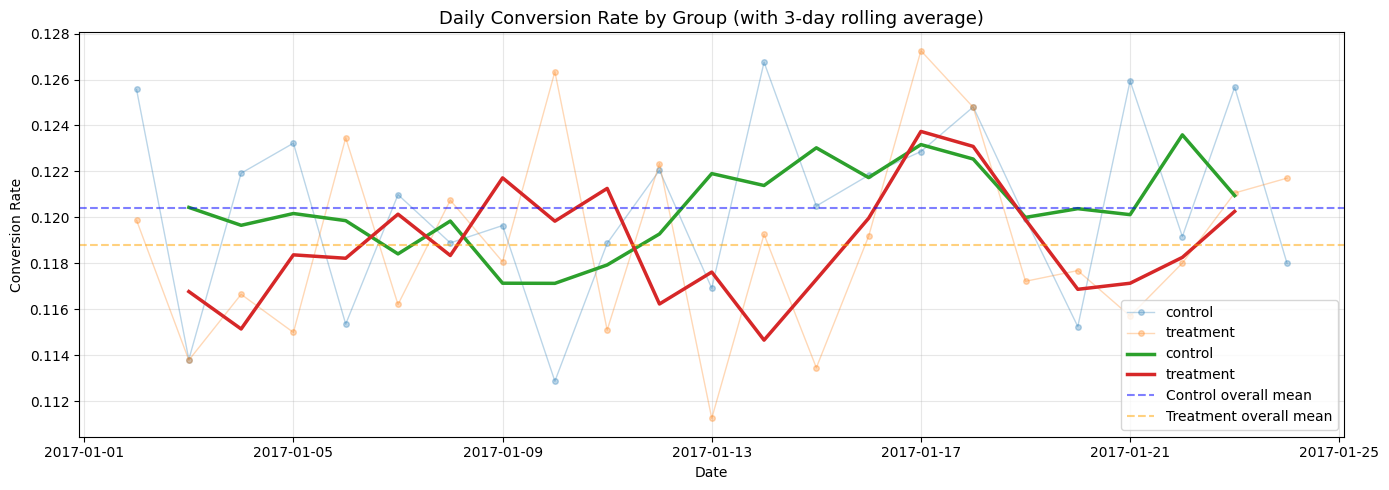

In [13]:
# Plot daily conversion rates for both groups with smoothed trend
import matplotlib.pyplot as plt

daily = df_clean.groupby(['date', 'group']).agg(
    users=('converted', 'count'),
    conversions=('converted', 'sum')
).reset_index()
daily['conversion_rate'] = daily['conversions'] / daily['users']
daily_pivot = daily.pivot(index='date', columns='group', values='conversion_rate')

# Rolling 3-day average to smooth out daily noise
daily_pivot_smooth = daily_pivot.rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
daily_pivot.plot(ax=ax, alpha=0.3, marker='o', markersize=4, linewidth=1)
daily_pivot_smooth.plot(ax=ax, linewidth=2.5, linestyle='-', alpha=1)

ax.set_title('Daily Conversion Rate by Group (with 3-day rolling average)', fontsize=13)
ax.set_ylabel('Conversion Rate')
ax.set_xlabel('Date')
ax.axhline(y=df_clean[df_clean['group']=='control']['converted'].mean(), 
           color='blue', linestyle='--', alpha=0.5, label='Control overall mean')
ax.axhline(y=df_clean[df_clean['group']=='treatment']['converted'].mean(), 
           color='orange', linestyle='--', alpha=0.5, label='Treatment overall mean')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('daily_conversion_smoothed.png', dpi=100, bbox_inches='tight')
plt.show()

**What the chart shows:** The two rolling-average lines cross around day 11-13. Treatment leads in the first half, then control pulls ahead and stays there. Notably, neither line has settled into a stable level by the time the experiment ends — both are still moving.

Two interpretations fit this pattern. The first is a novelty effect on treatment: the new page attracted initial attention because it was different, then performance regressed as users habituated. The second is a learning effect on control: returning users became more efficient with the familiar page over time.

Distinguishing between these would require either (a) cohort analysis separating new from returning users, or (b) a longer experiment that lets either effect stabilize. With 21 days of data, both stories are consistent with what we see.

# A/B Test Decision Memo: Landing Page Redesign

**To:** Product Manager  
**From:** Jaskirat Kaur, Data Analyst  
**Date:** May 2026  
**Status:** Pre-Ship Analysis Complete

---

## TL;DR — Recommendation

**Do not ship the new landing page as-is.** The test ran for 21 days across ~290K users and did not produce a statistically significant improvement in conversion rate. The observed effect was a -0.16 percentage point change (a 1.3% relative drop), which falls within the range of random variation expected under no true effect.

## What We Tested

A redesigned landing page (treatment) compared against the existing page (control). Users were randomly assigned 50/50, ran for 21 days from Jan 2 - Jan 24, 2017. Primary metric: conversion rate.

## Methodology

- **Data quality**: Removed 3,893 contaminated assignments (1.3% of users where group did not match landing page seen, likely caching or session bugs). Also removed 1 duplicate user record.
- **Final sample**: 290,584 unique users (145,274 control, 145,310 treatment), clean 50/50 split.
- **Primary test**: Two-proportion z-test (two-sided, α = 0.05).
- **Secondary analysis**: Segment by experiment phase (early vs late half) to check for time-dependent effects.


## Key Findings

**1. No statistically significant effect overall.**

Control converted at 12.04%, treatment at 11.88%. That's a -0.16 percentage point difference, or a 1.3% relative drop. The z-test gave p = 0.19, well above the 0.05 threshold. The 95% confidence interval for the difference runs from -0.39pp to +0.08pp, crossing zero, so we can't rule out that the true effect is nothing at all.

In plain terms: the new page isn't better, and might be slightly worse, but the data is consistent with no real effect either way.

**2. The picture changes when you look at the timeline.**

When I split the experiment into halves, two things showed up:

- Early phase (first 11 days): basically identical. Control 11.88%, treatment 11.85%, p = 0.85.
- Late phase (last 10 days): control 12.19%, treatment 11.91%, p = 0.10.

Control improved in the second half. Treatment didn't. The late-phase p-value of 0.10 isn't statistically significant, but it's approaching the threshold.

The rolling-average chart shows this more clearly than the split-half numbers. The two groups actually crossed around day 11-13. Treatment led for the first half, then fell behind.

Two interpretations are consistent with the data: a novelty effect on treatment (initial attention, then regression to baseline as users habituate), or a learning effect on control (returning users becoming more efficient with the familiar page). With 21 days of data, we cannot distinguish between these. Resolving the question would require cohort-level analysis separating new from returning users, or a longer experiment that lets either effect stabilize.

**3.  Experiment integrity verified.**
   Daily volume stable (mean 12,634 users/day after day 1). Daily treatment split stayed within 49.3%–50.6%. No drift in assignment randomization.
## Caveats

- The marginal late-phase signal (p=0.10) could be real or random variation and the dataset doesn't allow definitive separation.
- No user-level covariates (geography, traffic source, device, user tenure). Can't test heterogeneity beyond timing.
- This is a single A/B test on one metric (conversion). Real product decisions should also weigh guardrails (engagement, retention, downstream metrics).

## Methodological gaps and what I'd add in a v2

A few methodological refinements that would strengthen a re-analysis:

- **Daily peeking analysis.** Splitting the data into two halves by date is arbitrary. A more rigorous approach is to compute the cumulative p-value day by day and observe how it evolves. This would distinguish "trend not yet stable" from "we got unlucky early."
- **Formal sample ratio mismatch test.** The 50/50 split looked clean by eye, but the proper check is a chi-square test against the expected ratio. Visual inspection was enough here, but wouldn't be in a production setting.
- **Cohort separation.** Without separating new from returning users, we can't distinguish between the novelty-effect and learning-effect interpretations. The dataset doesn't include a user tenure flag, but in a real analysis I would push for this instrumentation before re-testing.
- **Heterogeneous treatment effects beyond timing.** Only segmented by experiment phase here. A production analysis would also cut by traffic source, device, geography, and user value tier.

## Recommended Next Steps

1. **Do not ship the current treatment.** The data does not support it, and the late-phase trend is mildly concerning.
2. **Before retesting, investigate three things:**  
   a. Was traffic source mix stable across the 21 days, or did the user base shift?  
   b. Are returning users disproportionately favoring the old (familiar) page? Check by user_id history if available.  
   c. Would a longer experiment (4+ weeks) reveal the late-phase pattern as real or as noise?
3. **Critical: a 21-day test was insufficient given the observed time dynamics**
   The crossover pattern at day 11-13 and continued divergence through day 24 indicate trajectories had not stabilized. Before any future test:
   - **Minimum 6 weeks duration** to allow novelty/learning effects to fully play out
   - **Cohort-based analysis** separating new vs returning users to isolate which segment drives the divergence
   - **Pre-registered analysis plan** with explicit decision rules to avoid being misled by mid-experiment trajectory changes
   - **Explicit guardrails** on engagement and bounce rate alongside conversion